In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import torchvision
import torchvision.transforms as T

device = 'cuda' if torch.cuda.is_available() else 'cpu'

torch.manual_seed(180180180)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [ ]:
# UNet Definition

class Conv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super().__init__()
    self.op = nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.GELU()
    )

  def forward(self, x):
    return self.op(x)

class DownConv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super().__init__()
    self.op = nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.GELU()
    )

  def forward(self, x):
    return self.op(x)

class UpConv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super().__init__()
    self.op = nn.Sequential(
        nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.GELU()
    )

  def forward(self, x):
    return self.op(x)

class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        self.pool = nn.AvgPool2d(kernel_size=7)
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.pool(x))

class Unflatten(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.op = nn.Sequential(
            nn.ConvTranspose2d(ch, ch, kernel_size=7, stride=7, padding=0),
            nn.BatchNorm2d(ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.op(x)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.op = nn.Sequential(
            Conv(in_ch, out_ch),
            Conv(out_ch, out_ch)
        )

    def forward(self, x):
        return self.op(x)

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.op = nn.Sequential(
            DownConv(in_ch, out_ch),
            ConvBlock(out_ch, out_ch)
        )

    def forward(self, x):
        return self.op(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.op = nn.Sequential(
            UpConv(in_ch, out_ch),
            ConvBlock(out_ch, out_ch)
        )

    def forward(self, x):
        return self.op(x)

class UNet(nn.Module):
    def __init__(self, D=128):
      super().__init__()

      # Encoder
      self.enc0 = ConvBlock(1, D)
      self.down1 = DownBlock(D, D)
      self.down2 = DownBlock(D, 2*D)

      # Bottleneck
      self.flatten = Flatten()
      self.unflatten = Unflatten(2*D)

      # Decoder
      self.up1 = UpBlock(4*D, 2*D)
      self.up2 = UpBlock(3*D, D)

      # Final
      self.final_block = ConvBlock(2*D, D)
      self.out = nn.Conv2d(D, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
      # Encoder
      x0 = self.enc0(x)
      x1 = self.down1(x0)
      x2 = self.down2(x1)

      # Bottleneck
      z = self.flatten(x2)
      z = self.unflatten(z)

      # Decoder
      z = torch.cat([z, x2], dim=1)
      z = self.up1(z)

      z = torch.cat([z, x1], dim=1)
      z = self.up2(z)

      z = torch.cat([z, x0], dim=1)
      z = self.final_block(z)

      return self.out(z)



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.63MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


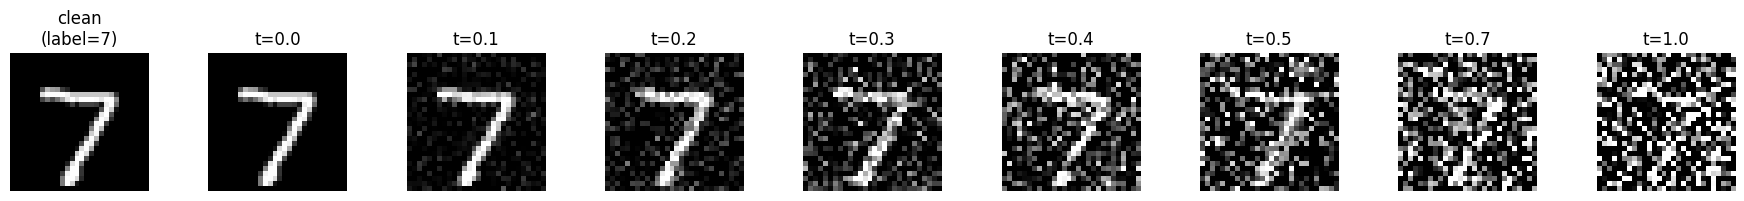

In [ ]:
OUT_DIR = "deliverables"
os.makedirs(OUT_DIR)

transform = T.ToTensor()
testset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

x0, y0 = testset[0]
x0 = x0.to(device)


@torch.no_grad()
def add_noise(x0, t):
    eps = torch.randn_like(x0)
    return torch.clamp(x0 + t * eps, 0.0, 1.0)

t_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]

noised = [add_noise(x0, t).detach().cpu() for t in t_values]

fig, axes = plt.subplots(1, len(t_values) + 1, figsize=(2*(len(t_values)+1), 2))
axes[0].imshow(x0.detach().cpu().squeeze(0), cmap="gray")
axes[0].set_title(f"clean\n(label={y0})")
axes[0].axis("off")

for i, (t, xt) in enumerate(zip(t_values, noised), start=1):
    axes[i].imshow(xt.squeeze(0), cmap="gray")
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")

plt.tight_layout()

out_path = os.path.join(OUT_DIR, "part1_2_noising_process.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

Epoch 1 | step 0 | loss 0.229504
Epoch 1 | step 100 | loss 0.018122
Epoch 1 | step 200 | loss 0.014475


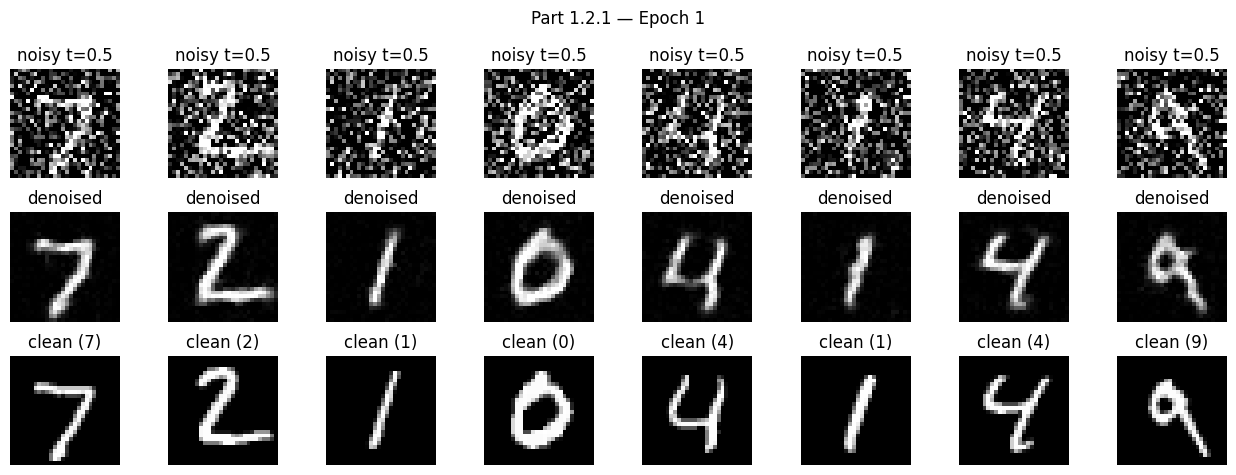

Saved: deliverables/part1_2_1_denoise_epoch1.png
Epoch 2 | step 300 | loss 0.014222
Epoch 2 | step 400 | loss 0.011852
Epoch 3 | step 500 | loss 0.012016
Epoch 3 | step 600 | loss 0.011829
Epoch 3 | step 700 | loss 0.010906
Epoch 4 | step 800 | loss 0.010876
Epoch 4 | step 900 | loss 0.010321
Epoch 5 | step 1000 | loss 0.010647
Epoch 5 | step 1100 | loss 0.010792


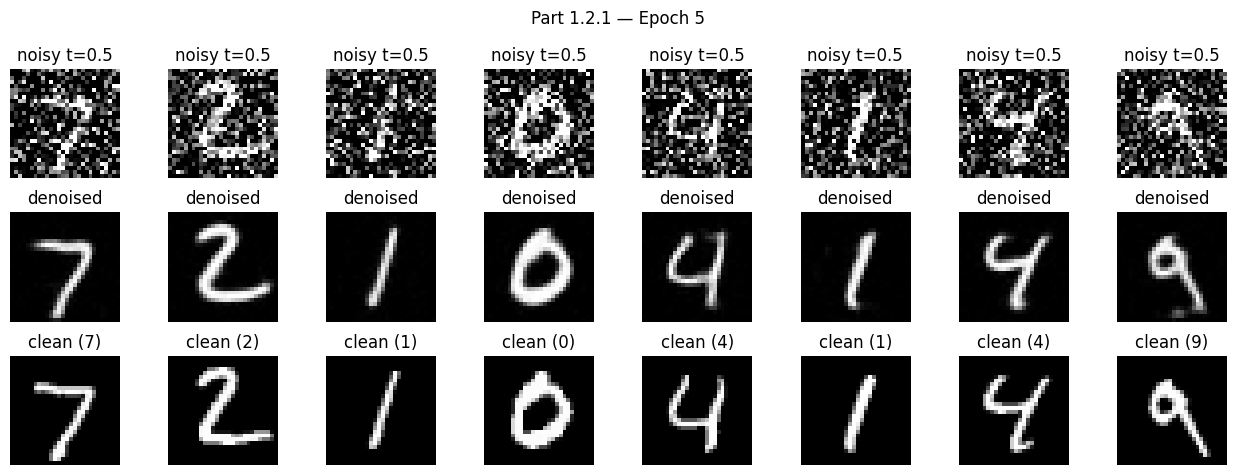

Saved: deliverables/part1_2_1_denoise_epoch5.png


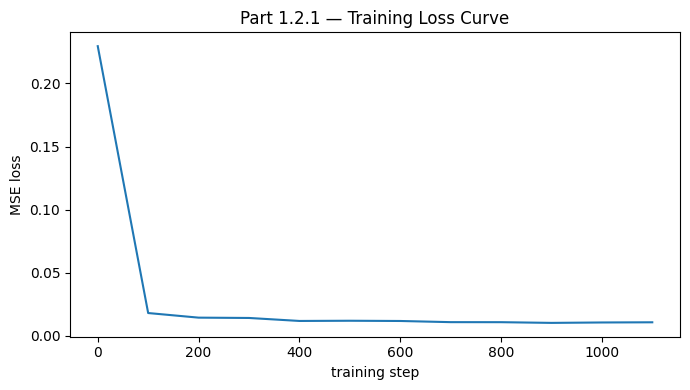

Saved: deliverables/part1_2_1_training_loss_curve.png


In [ ]:
trainset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
testset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=256, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

@torch.no_grad()
def save_denoising(epoch, t_val=0.5, n_show=8):
    model.eval()
    x0, y = next(iter(test_loader))
    x0 = x0[:n_show].to(device)
    y = y[:n_show]

    t = torch.full((x0.size(0), 1, 1, 1), t_val, device=device)
    xt = add_noise(x0, t)
    x_hat = torch.clamp(model(xt), 0.0, 1.0)

    fig, axes = plt.subplots(3, n_show, figsize=(1.6*n_show, 4.8))
    for i in range(n_show):
        axes[0, i].imshow(xt[i].cpu().squeeze(), cmap="gray")
        axes[0, i].set_title(f"noisy t={t_val}")
        axes[0, i].axis("off")

        axes[1, i].imshow(x_hat[i].cpu().squeeze(), cmap="gray")
        axes[1, i].set_title("denoised")
        axes[1, i].axis("off")

        axes[2, i].imshow(x0[i].cpu().squeeze(), cmap="gray")
        axes[2, i].set_title(f"clean ({int(y[i])})")
        axes[2, i].axis("off")

    plt.suptitle(f"Part 1.2.1 — Epoch {epoch}")
    plt.tight_layout()

    path = os.path.join(OUT_DIR, f"part1_2_1_denoise_epoch{epoch}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

num_epochs = 5
log_every = 100
loss_history = []
step_history = []
step = 0

for epoch in range(1, num_epochs + 1):
    model.train()
    for x0, _ in train_loader:
        x0 = x0.to(device)

        t = torch.rand((x0.size(0), 1, 1, 1), device=device)
        xt = add_noise(x0, t)

        optimizer.zero_grad()
        x_hat = model(xt)
        loss = criterion(x_hat, x0)
        loss.backward()
        optimizer.step()

        if step % log_every == 0:
            loss_history.append(loss.item())
            step_history.append(step)
            print(f"Epoch {epoch} | step {step} | loss {loss.item():.6f}")

        step += 1

    if epoch in (1, 5):
        save_denoising(epoch)

plt.figure(figsize=(7,4))
plt.plot(step_history, loss_history)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Part 1.2.1 — Training Loss Curve")
plt.tight_layout()

loss_path = os.path.join(OUT_DIR, "part1_2_1_training_loss_curve.png")
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", loss_path)


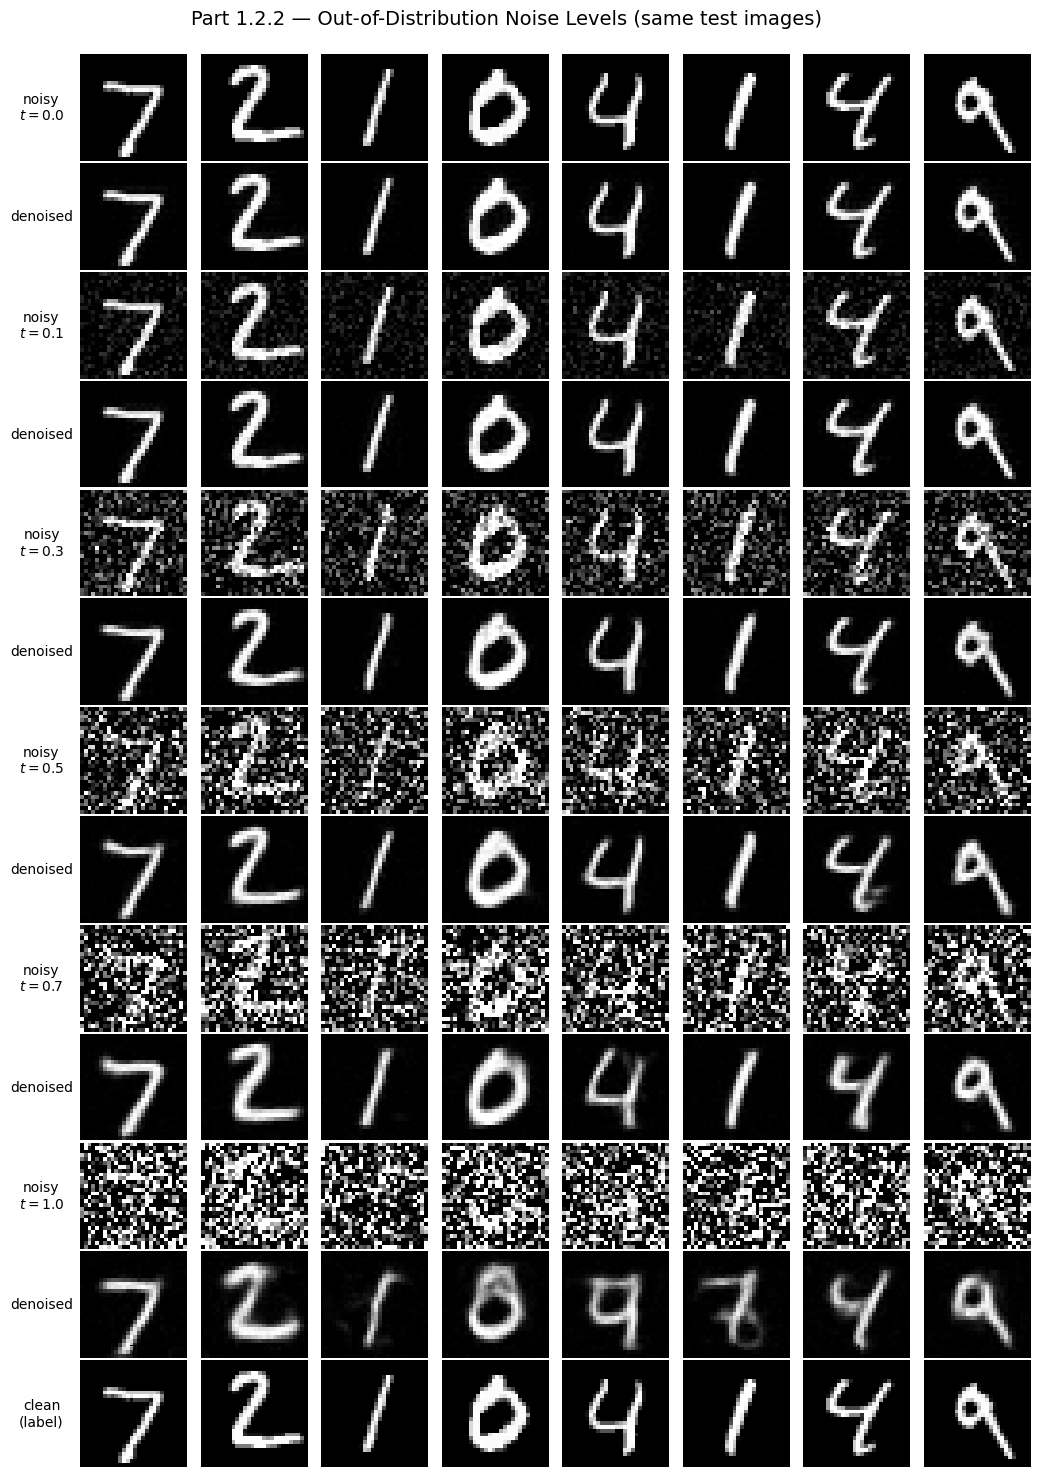

Saved: deliverables/part1_2_2_ood_noise_levels.png


In [ ]:
@torch.no_grad()
def save_ood_grid(t_list=(0.0, 0.1, 0.3, 0.5, 0.7, 1.0), n_show=8, pad=0.02):
    model.eval()

    x0, y = next(iter(test_loader))
    x0 = x0[:n_show].to(device)
    y = y[:n_show]

    n_rows = 2 * len(t_list) + 1
    fig, axes = plt.subplots(
        n_rows, n_show,
        figsize=(1.35 * n_show, 1.15 * n_rows),
        constrained_layout=False
    )

    def _imshow(ax, img):
        ax.imshow(img, cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)

    row = 0
    for t_val in t_list:
        t = torch.full((x0.size(0), 1, 1, 1), float(t_val), device=device)
        xt = torch.clamp(add_noise(x0, t), 0.0, 1.0)
        xhat = torch.clamp(model(xt), 0.0, 1.0)

        for i in range(n_show):
            _imshow(axes[row, i],   xt[i].detach().cpu().squeeze(0))
            _imshow(axes[row+1, i], xhat[i].detach().cpu().squeeze(0))

        axes[row, 0].set_ylabel(f"noisy\n$t={t_val}$", rotation=0, labelpad=28, va="center", fontsize=10)
        axes[row+1, 0].set_ylabel("denoised", rotation=0, labelpad=28, va="center", fontsize=10)

        row += 2

    for i in range(n_show):
        _imshow(axes[row, i], x0[i].detach().cpu().squeeze(0))
        axes[row, i].set_title(f"{int(y[i])}", fontsize=10, pad=4)
    axes[row, 0].set_ylabel("clean\n(label)", rotation=0, labelpad=28, va="center", fontsize=10)

    fig.suptitle("Part 1.2.2 — Out-of-Distribution Noise Levels (same test images)", fontsize=14, y=0.995)
    plt.subplots_adjust(left=0.10, right=0.99, top=0.965, bottom=0.02, wspace=pad, hspace=pad)

    out_path = os.path.join(OUT_DIR, "part1_2_2_ood_noise_levels.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Saved:", out_path)

save_ood_grid(t_list=(0.0, 0.1, 0.3, 0.5, 0.7, 1.0), n_show=8, pad=0.02)


Epoch 1 | step 0 | loss 0.258701
Epoch 1 | step 100 | loss 0.068672
Epoch 1 | step 200 | loss 0.068180
==> Epoch 1 avg loss: 0.074373


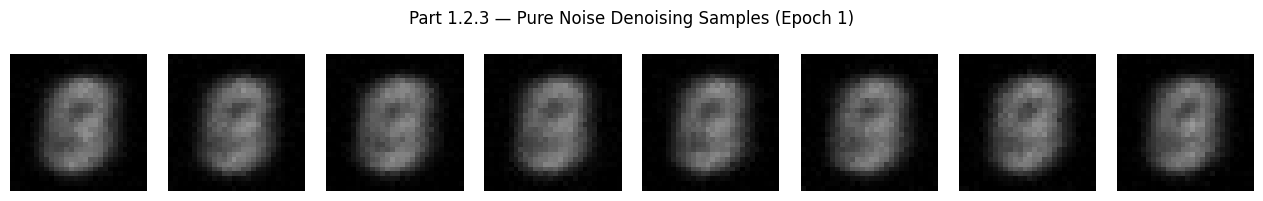

Saved: deliverables/part1_2_3_pure_noise_epoch1.png
Epoch 2 | step 300 | loss 0.067472
Epoch 2 | step 400 | loss 0.066446
==> Epoch 2 avg loss: 0.067567
Epoch 3 | step 500 | loss 0.067416
Epoch 3 | step 600 | loss 0.065984
Epoch 3 | step 700 | loss 0.069351
==> Epoch 3 avg loss: 0.067442
Epoch 4 | step 800 | loss 0.067726
Epoch 4 | step 900 | loss 0.068405
==> Epoch 4 avg loss: 0.067453
Epoch 5 | step 1000 | loss 0.066746
Epoch 5 | step 1100 | loss 0.066393
==> Epoch 5 avg loss: 0.067424


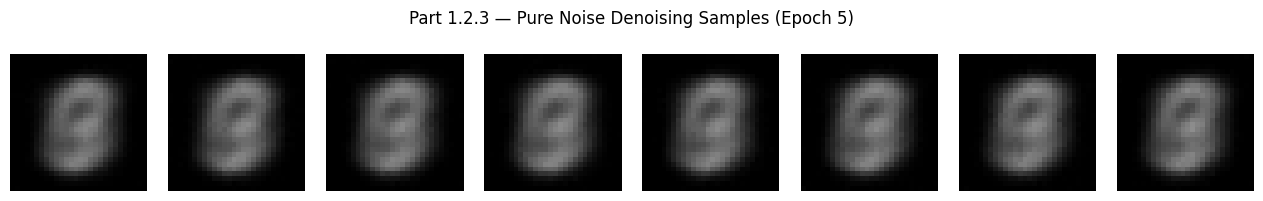

Saved: deliverables/part1_2_3_pure_noise_epoch5.png


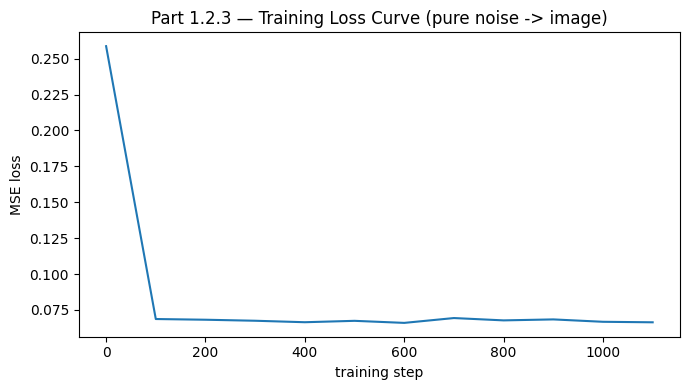

Saved: deliverables/part1_2_3_training_loss_curve.png


In [ ]:
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)

model_pure = UNet(D=128).to(device)
opt_pure = torch.optim.Adam(model_pure.parameters(), lr=1e-4)
criterion = nn.MSELoss()

@torch.no_grad()
def save_pure_noise_samples(epoch, n_show=8):
    model_pure.eval()

    g = torch.Generator(device=device)
    g.manual_seed(0)
    z = torch.randn((n_show, 1, 28, 28), device=device, generator=g)

    x_hat = torch.clamp(model_pure(z), 0.0, 1.0)

    fig, axes = plt.subplots(1, n_show, figsize=(1.6*n_show, 2))
    for i in range(n_show):
        axes[i].imshow(x_hat[i].detach().cpu().squeeze(0), cmap="gray", vmin=0.0, vmax=1.0)
        axes[i].axis("off")
    plt.suptitle(f"Part 1.2.3 — Pure Noise Denoising Samples (Epoch {epoch})")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"part1_2_3_pure_noise_epoch{epoch}.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

num_epochs = 5
log_every = 100
loss_hist, step_hist = [], []
step = 0

for epoch in range(1, num_epochs + 1):
    model_pure.train()
    running = 0.0
    n_batches = 0

    for x0, _ in train_loader:
        x0 = x0.to(device)

        z = torch.randn_like(x0)

        opt_pure.zero_grad()
        x_hat = model_pure(z)
        loss = criterion(x_hat, x0)
        loss.backward()
        opt_pure.step()

        running += loss.item()
        n_batches += 1

        if step % log_every == 0:
            loss_hist.append(loss.item())
            step_hist.append(step)
            print(f"Epoch {epoch} | step {step} | loss {loss.item():.6f}")

        step += 1

    print(f"==> Epoch {epoch} avg loss: {running/max(1,n_batches):.6f}")

    if epoch in (1, 5):
        save_pure_noise_samples(epoch, n_show=8)

plt.figure(figsize=(7,4))
plt.plot(step_hist, loss_hist)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Part 1.2.3 — Training Loss Curve (pure noise -> image)")
plt.tight_layout()

loss_path = os.path.join(OUT_DIR, "part1_2_3_training_loss_curve.png")
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", loss_path)


In [ ]:
class FCBlock(nn.Module):
    def __init__(self, f_in: int, f_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(f_in, f_out),
            nn.GELU(),
            nn.Linear(f_out, f_out),
        )

    def forward(self, x):
        return self.net(x)

class TimeConditionedUNet(nn.Module):
    def __init__(self, D: int = 64):
        super().__init__()
        self.D = D

        self.enc0  = ConvBlock(1, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        self.flatten   = Flatten()
        self.unflatten = Unflatten(2*D)

        self.up1 = UpBlock(4*D, 2*D)
        self.up2 = UpBlock(3*D, D)

        self.final_block = ConvBlock(2*D, D)
        self.out = nn.Conv2d(D, 1, kernel_size=3, stride=1, padding=1)

        self.fc1_t = FCBlock(1, 2*D)
        self.fc2_t = FCBlock(1, 2*D)

    def forward(self, x, t):
        if t.dim() == 1:
            t = t[:, None]
        t = t.clamp(0.0, 1.0)

        t1 = self.fc1_t(t).view(-1, 2*self.D, 1, 1)
        t2 = self.fc2_t(t).view(-1, 2*self.D, 1, 1)

        x0 = self.enc0(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)

        z = self.flatten(x2)
        z = self.unflatten(z)

        z = z * t1

        z = torch.cat([z, x2], dim=1)
        z = self.up1(z)

        z = z * t2

        z = torch.cat([z, x1], dim=1)
        z = self.up2(z)

        z = torch.cat([z, x0], dim=1)
        z = self.final_block(z)

        return self.out(z)

epoch 1 step 0 loss 1.132377
epoch 1 step 100 loss 0.231205
epoch 1 step 200 loss 0.189468
epoch 1 step 300 loss 0.142138
epoch 1 step 400 loss 0.154037
epoch 1 step 500 loss 0.134525
epoch 1 step 600 loss 0.124692
epoch 1 step 700 loss 0.147318
epoch 1 step 800 loss 0.158524
epoch 1 step 900 loss 0.116799


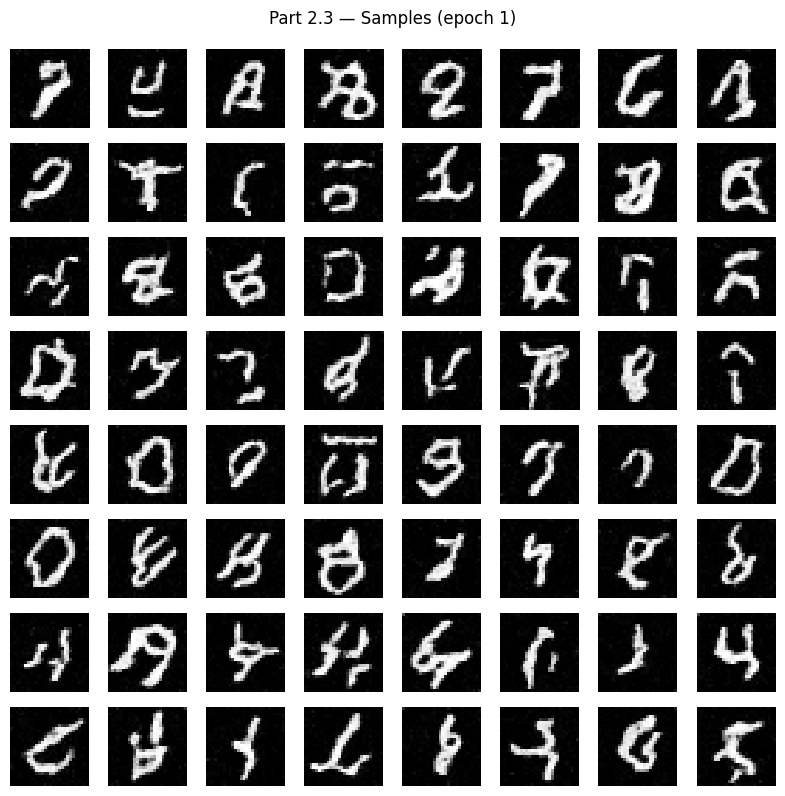

Saved: deliverables/part2_3_samples_epoch1.png
epoch 2 step 1000 loss 0.117078
epoch 2 step 1100 loss 0.125840
epoch 2 step 1200 loss 0.105277
epoch 2 step 1300 loss 0.118211
epoch 2 step 1400 loss 0.118250
epoch 2 step 1500 loss 0.121294
epoch 2 step 1600 loss 0.102375
epoch 2 step 1700 loss 0.125255
epoch 2 step 1800 loss 0.109202
epoch 3 step 1900 loss 0.108842
epoch 3 step 2000 loss 0.112696
epoch 3 step 2100 loss 0.112974
epoch 3 step 2200 loss 0.118106
epoch 3 step 2300 loss 0.100388
epoch 3 step 2400 loss 0.113777
epoch 3 step 2500 loss 0.100176
epoch 3 step 2600 loss 0.111535
epoch 3 step 2700 loss 0.117464
epoch 3 step 2800 loss 0.105744
epoch 4 step 2900 loss 0.105341
epoch 4 step 3000 loss 0.094504
epoch 4 step 3100 loss 0.116882
epoch 4 step 3200 loss 0.118716
epoch 4 step 3300 loss 0.095417
epoch 4 step 3400 loss 0.105357
epoch 4 step 3500 loss 0.095761
epoch 4 step 3600 loss 0.112102
epoch 4 step 3700 loss 0.101339
epoch 5 step 3800 loss 0.103551
epoch 5 step 3900 loss 0.

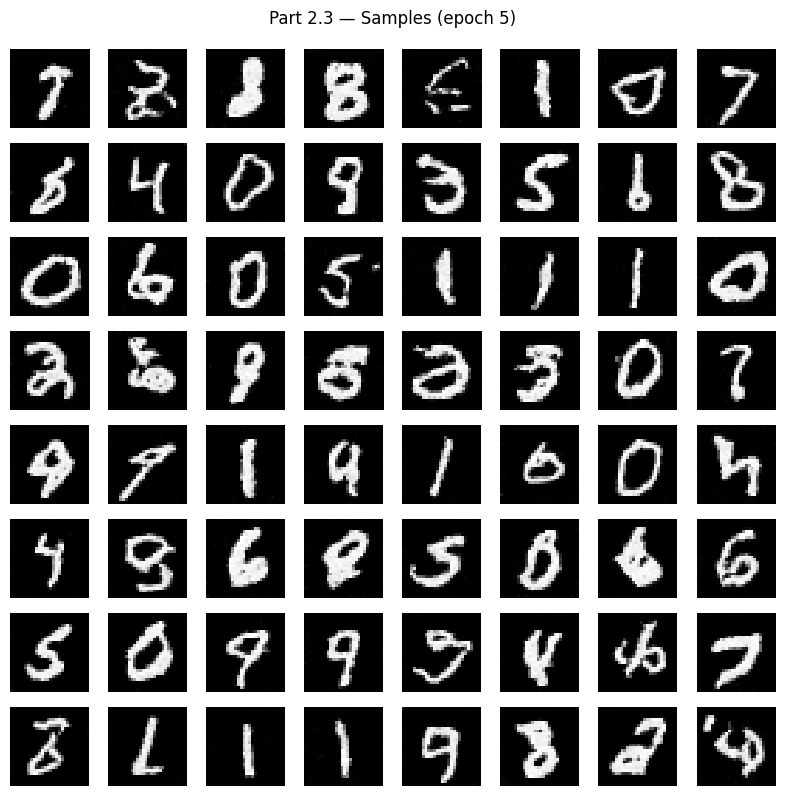

Saved: deliverables/part2_3_samples_epoch5.png
epoch 6 step 4700 loss 0.103555
epoch 6 step 4800 loss 0.089225
epoch 6 step 4900 loss 0.093163
epoch 6 step 5000 loss 0.099001
epoch 6 step 5100 loss 0.095406
epoch 6 step 5200 loss 0.097184
epoch 6 step 5300 loss 0.101631
epoch 6 step 5400 loss 0.095230
epoch 6 step 5500 loss 0.098260
epoch 6 step 5600 loss 0.092482
epoch 7 step 5700 loss 0.094711
epoch 7 step 5800 loss 0.098724
epoch 7 step 5900 loss 0.094608
epoch 7 step 6000 loss 0.091998
epoch 7 step 6100 loss 0.092898
epoch 7 step 6200 loss 0.092268
epoch 7 step 6300 loss 0.089794
epoch 7 step 6400 loss 0.101865
epoch 7 step 6500 loss 0.092069
epoch 8 step 6600 loss 0.108195
epoch 8 step 6700 loss 0.094884
epoch 8 step 6800 loss 0.096951
epoch 8 step 6900 loss 0.085820
epoch 8 step 7000 loss 0.097709
epoch 8 step 7100 loss 0.095018
epoch 8 step 7200 loss 0.102299
epoch 8 step 7300 loss 0.098550
epoch 8 step 7400 loss 0.100541
epoch 8 step 7500 loss 0.104703
epoch 9 step 7600 loss 0.

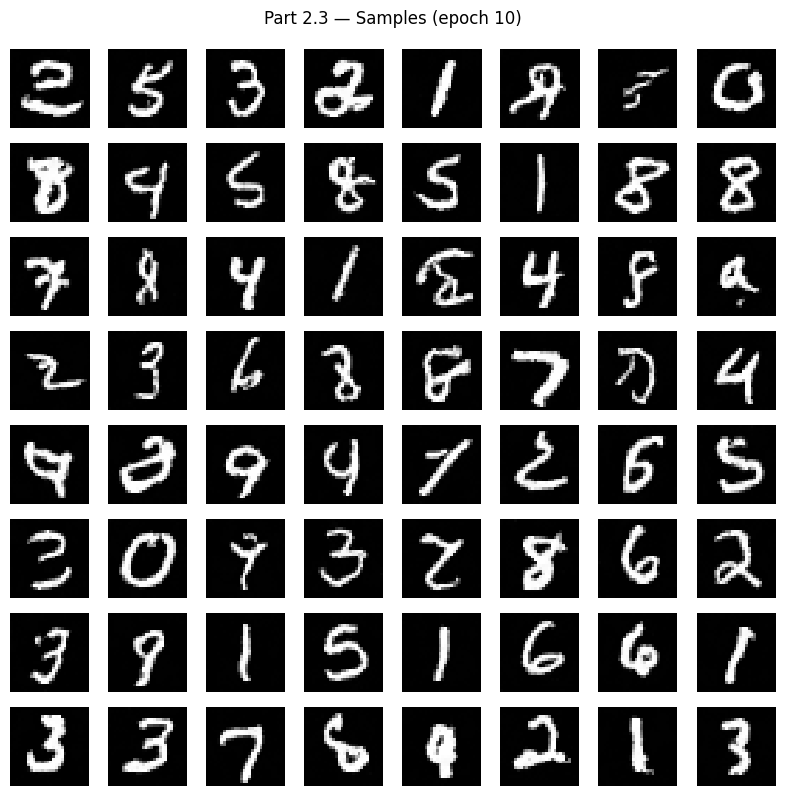

Saved: deliverables/part2_3_samples_epoch10.png


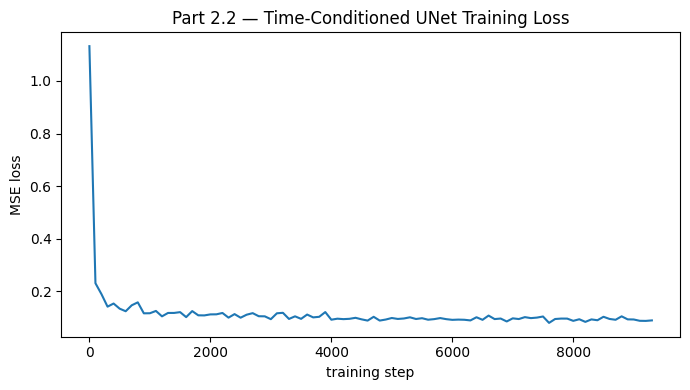

Saved: deliverables/part2_2_time_conditioned_loss_curve.png


In [ ]:
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

model_tc = TimeConditionedUNet(D=64).to(device)
opt = torch.optim.Adam(model_tc.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
criterion = nn.MSELoss()

@torch.no_grad()
def sample_time_conditioned(model, n=64, n_steps=300):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n,), k / n_steps, device=device)
        x = x + dt * model(x, t)
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def save_sample_grid(samples, epoch):
    m = int(samples.size(0) ** 0.5)
    samples = samples[:m*m].detach().cpu()
    fig, axes = plt.subplots(m, m, figsize=(8, 8))
    for i in range(m*m):
        ax = axes[i // m, i % m]
        ax.imshow(samples[i].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    plt.suptitle(f"Part 2.3 — Samples (epoch {epoch})", y=0.99)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f"part2_3_samples_epoch{epoch}.png")
    plt.savefig(p, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Saved:", p)

num_epochs = 10
log_every = 100
loss_hist, step_hist = [], []
step = 0

for epoch in range(1, num_epochs + 1):
    model_tc.train()
    for x0, _ in train_loader:
        x0 = x0.to(device)
        eps = torch.randn_like(x0)
        t = torch.rand((x0.size(0),), device=device)
        xt = (1.0 - t).view(-1,1,1,1) * eps + t.view(-1,1,1,1) * x0
        v_star = x0 - eps

        opt.zero_grad()
        v_pred = model_tc(xt, t)
        loss = criterion(v_pred, v_star)
        loss.backward()
        opt.step()

        if step % log_every == 0:
            loss_hist.append(loss.item())
            step_hist.append(step)
            print(f"epoch {epoch} step {step} loss {loss.item():.6f}")

        step += 1

    scheduler.step()

    if epoch in (1, 5, 10):
        samples = sample_time_conditioned(model_tc, n=64, n_steps=300)
        save_sample_grid(samples, epoch)

plt.figure(figsize=(7,4))
plt.plot(step_hist, loss_hist)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Part 2.2 — Time-Conditioned UNet Training Loss")
plt.tight_layout()
path = os.path.join(OUT_DIR, "part2_2_time_conditioned_loss_curve.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", path)


In [ ]:
class ClassConditionedUNet(nn.Module):
    def __init__(self, D=64, num_classes=10, p_uncond=0.1):
        super().__init__()
        self.D = D
        self.num_classes = num_classes
        self.p_uncond = p_uncond

        self.enc0  = ConvBlock(1, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)

        self.flatten   = Flatten()
        self.unflatten = Unflatten(2*D)

        self.up1 = UpBlock(4*D, 2*D)
        self.up2 = UpBlock(3*D, D)

        self.final_block = ConvBlock(2*D, D)
        self.out = nn.Conv2d(D, 1, kernel_size=3, stride=1, padding=1)

        self.fc1_t = FCBlock(1, 2*D)
        self.fc2_t = FCBlock(1, 2*D)
        self.fc1_c = FCBlock(num_classes, 2*D)
        self.fc2_c = FCBlock(num_classes, 2*D)

    def forward(self, x, t, c=None):
        if t.dim() == 1:
            t = t[:, None]
        t = t.clamp(0.0, 1.0)

        if c is None:
            c = torch.zeros((x.size(0), self.num_classes), device=x.device, dtype=x.dtype)
        else:
            if c.dim() == 1:
                c = torch.nn.functional.one_hot(c, num_classes=self.num_classes).to(dtype=x.dtype, device=x.device)
            else:
                c = c.to(dtype=x.dtype, device=x.device)
            if self.training and self.p_uncond > 0:
                drop = (torch.rand((x.size(0),), device=x.device) < self.p_uncond).to(x.dtype).view(-1, 1)
                c = c * (1.0 - drop)

        t1 = self.fc1_t(t).view(-1, 2*self.D, 1, 1)
        t2 = self.fc2_t(t).view(-1, 2*self.D, 1, 1)
        c1 = self.fc1_c(c).view(-1, 2*self.D, 1, 1)
        c2 = self.fc2_c(c).view(-1, 2*self.D, 1, 1)

        x0 = self.enc0(x)
        x1 = self.down1(x0)
        x2 = self.down2(x1)

        z = self.flatten(x2)
        z = self.unflatten(z)

        z = c1 * z + t1

        z = torch.cat([z, x2], dim=1)
        z = self.up1(z)

        z = c2 * z + t2

        z = torch.cat([z, x1], dim=1)
        z = self.up2(z)

        z = torch.cat([z, x0], dim=1)
        z = self.final_block(z)

        return self.out(z)

epoch 1 step 0 loss 1.190270
epoch 1 step 100 loss 0.229503
epoch 1 step 200 loss 0.164231
epoch 1 step 300 loss 0.139917
epoch 1 step 400 loss 0.141451
epoch 1 step 500 loss 0.188298
epoch 1 step 600 loss 0.131040
epoch 1 step 700 loss 0.133724
epoch 1 step 800 loss 0.122681
epoch 1 step 900 loss 0.132952


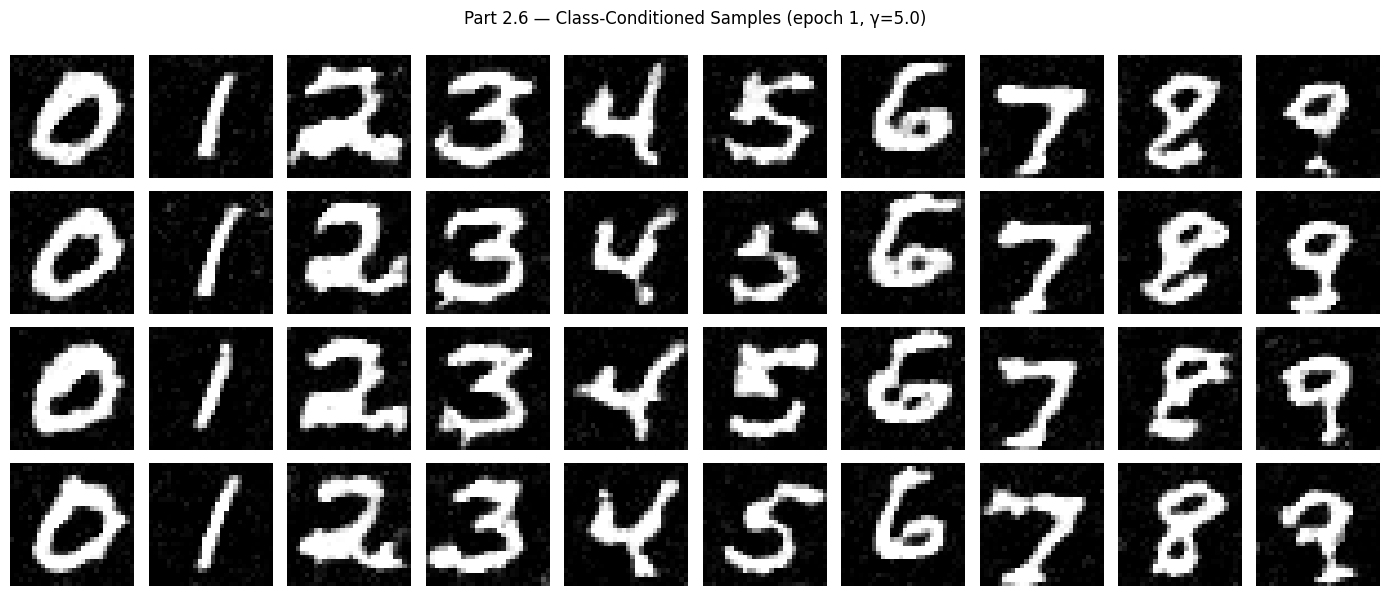

Saved: deliverables/part2_6_class_conditioned_epoch1.png
epoch 2 step 1000 loss 0.125914
epoch 2 step 1100 loss 0.105906
epoch 2 step 1200 loss 0.119142
epoch 2 step 1300 loss 0.138782
epoch 2 step 1400 loss 0.109699
epoch 2 step 1500 loss 0.110285
epoch 2 step 1600 loss 0.122265
epoch 2 step 1700 loss 0.113173
epoch 2 step 1800 loss 0.105953
epoch 3 step 1900 loss 0.099011
epoch 3 step 2000 loss 0.094741
epoch 3 step 2100 loss 0.100755
epoch 3 step 2200 loss 0.102427
epoch 3 step 2300 loss 0.109148
epoch 3 step 2400 loss 0.094631
epoch 3 step 2500 loss 0.100947
epoch 3 step 2600 loss 0.109415
epoch 3 step 2700 loss 0.110033
epoch 3 step 2800 loss 0.100810
epoch 4 step 2900 loss 0.112304
epoch 4 step 3000 loss 0.100753
epoch 4 step 3100 loss 0.112367
epoch 4 step 3200 loss 0.103316
epoch 4 step 3300 loss 0.100937
epoch 4 step 3400 loss 0.089647
epoch 4 step 3500 loss 0.099818
epoch 4 step 3600 loss 0.096507
epoch 4 step 3700 loss 0.089742
epoch 5 step 3800 loss 0.111509
epoch 5 step 39

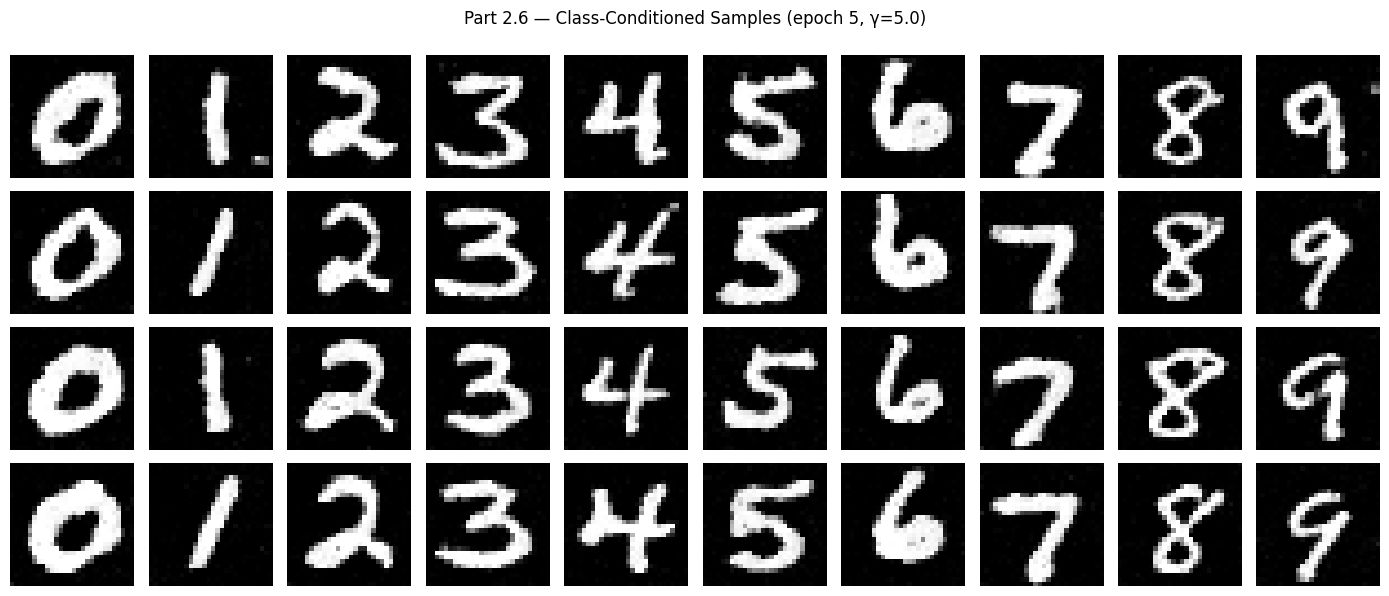

Saved: deliverables/part2_6_class_conditioned_epoch5.png
epoch 6 step 4700 loss 0.115929
epoch 6 step 4800 loss 0.088372
epoch 6 step 4900 loss 0.090372
epoch 6 step 5000 loss 0.102466
epoch 6 step 5100 loss 0.088517
epoch 6 step 5200 loss 0.091103
epoch 6 step 5300 loss 0.085253
epoch 6 step 5400 loss 0.082561
epoch 6 step 5500 loss 0.101574
epoch 6 step 5600 loss 0.088000
epoch 7 step 5700 loss 0.092818
epoch 7 step 5800 loss 0.095265
epoch 7 step 5900 loss 0.087819
epoch 7 step 6000 loss 0.085572
epoch 7 step 6100 loss 0.107149
epoch 7 step 6200 loss 0.079888
epoch 7 step 6300 loss 0.084992
epoch 7 step 6400 loss 0.087764
epoch 7 step 6500 loss 0.108016
epoch 8 step 6600 loss 0.081663
epoch 8 step 6700 loss 0.081253
epoch 8 step 6800 loss 0.095745
epoch 8 step 6900 loss 0.080225
epoch 8 step 7000 loss 0.092266
epoch 8 step 7100 loss 0.087767
epoch 8 step 7200 loss 0.093701
epoch 8 step 7300 loss 0.086907
epoch 8 step 7400 loss 0.083056
epoch 8 step 7500 loss 0.091299
epoch 9 step 76

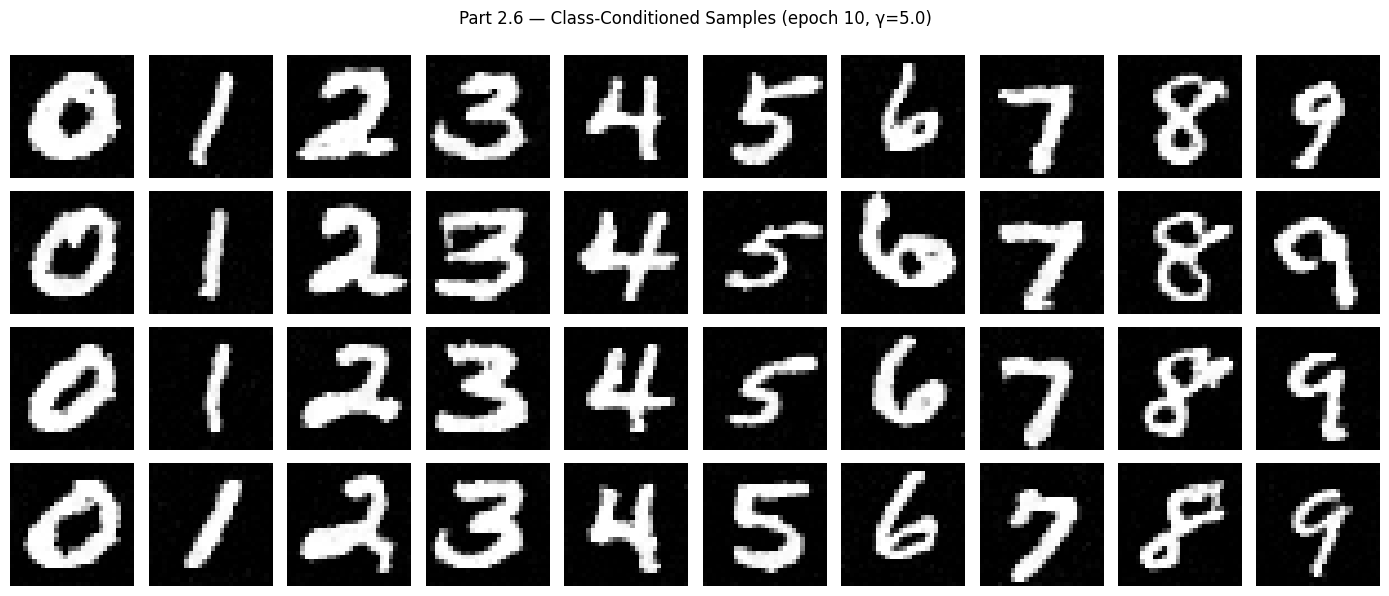

Saved: deliverables/part2_6_class_conditioned_epoch10.png


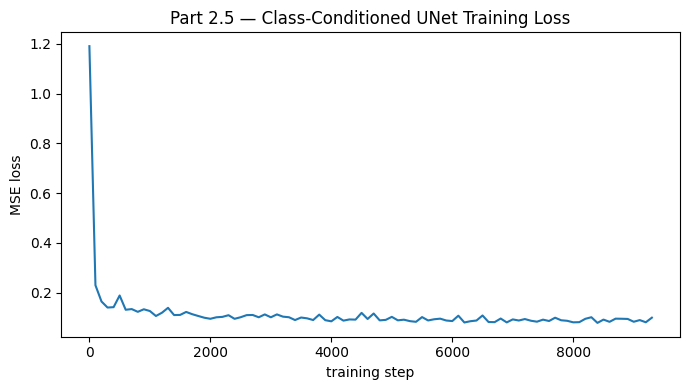

Saved: deliverables/part2_5_class_conditioned_loss_curve.png


In [ ]:
trainset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

model_cc = ClassConditionedUNet(D=64, num_classes=10, p_uncond=0.1).to(device)
opt = torch.optim.Adam(model_cc.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.95)
criterion = nn.MSELoss()

@torch.no_grad()
def sample_cc(model, digit, n=4, n_steps=300, gamma=5.0):
    model.eval()
    x = torch.randn(n, 1, 28, 28, device=device)
    c = torch.full((n,), int(digit), device=device, dtype=torch.long)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n,), k / n_steps, device=device)
        v_u = model(x, t, None)
        v_c = model(x, t, c)
        v = v_u + gamma * (v_c - v_u)
        x = x + dt * v
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def save_cc_grid(model, epoch, n_per_digit=4, n_steps=300, gamma=5.0):
    rows = []
    for d in range(10):
        rows.append(sample_cc(model, d, n=n_per_digit, n_steps=n_steps, gamma=gamma))
    grid = torch.cat(rows, dim=0).detach().cpu()
    fig, axes = plt.subplots(n_per_digit, 10, figsize=(14, 6))
    for r in range(n_per_digit):
        for d in range(10):
            idx = d*n_per_digit + r
            ax = axes[r, d]
            ax.imshow(grid[idx].squeeze(0), cmap="gray", vmin=0.0, vmax=1.0, interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values():
                s.set_visible(False)
    plt.suptitle(f"Part 2.6 — Class-Conditioned Samples (epoch {epoch}, γ={gamma})", y=0.99)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f"part2_6_class_conditioned_epoch{epoch}.png")
    plt.savefig(p, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Saved:", p)

num_epochs = 10
log_every = 100
loss_hist, step_hist = [], []
step = 0

for epoch in range(1, num_epochs + 1):
    model_cc.train()
    for x0, y in train_loader:
        x0 = x0.to(device)
        y = y.to(device)

        eps = torch.randn_like(x0)
        t = torch.rand((x0.size(0),), device=device)
        xt = (1.0 - t).view(-1,1,1,1) * eps + t.view(-1,1,1,1) * x0
        v_star = x0 - eps

        opt.zero_grad()
        loss = criterion(model_cc(xt, t, y), v_star)
        loss.backward()
        opt.step()

        if step % log_every == 0:
            loss_hist.append(loss.item())
            step_hist.append(step)
            print(f"epoch {epoch} step {step} loss {loss.item():.6f}")

        step += 1

    scheduler.step()

    if epoch in (1, 5, 10):
        save_cc_grid(model_cc, epoch, n_per_digit=4, n_steps=300, gamma=5.0)

plt.figure(figsize=(7,4))
plt.plot(step_hist, loss_hist)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Part 2.5 — Class-Conditioned UNet Training Loss")
plt.tight_layout()
p = os.path.join(OUT_DIR, "part2_5_class_conditioned_loss_curve.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", p)


[no-sched] epoch 1 step 0 loss 1.246869
[no-sched] epoch 1 step 100 loss 0.151806
[no-sched] epoch 1 step 200 loss 0.149715
[no-sched] epoch 1 step 300 loss 0.147017
[no-sched] epoch 1 step 400 loss 0.144264
[no-sched] epoch 1 step 500 loss 0.134243
[no-sched] epoch 1 step 600 loss 0.121182
[no-sched] epoch 1 step 700 loss 0.112060
[no-sched] epoch 1 step 800 loss 0.109915
[no-sched] epoch 1 step 900 loss 0.107241
[no-sched] epoch 2 step 1000 loss 0.128183
[no-sched] epoch 2 step 1100 loss 0.105948
[no-sched] epoch 2 step 1200 loss 0.095664
[no-sched] epoch 2 step 1300 loss 0.098469
[no-sched] epoch 2 step 1400 loss 0.118562
[no-sched] epoch 2 step 1500 loss 0.100160
[no-sched] epoch 2 step 1600 loss 0.100662
[no-sched] epoch 2 step 1700 loss 0.092556
[no-sched] epoch 2 step 1800 loss 0.095454
[no-sched] epoch 3 step 1900 loss 0.099022
[no-sched] epoch 3 step 2000 loss 0.085800
[no-sched] epoch 3 step 2100 loss 0.104748
[no-sched] epoch 3 step 2200 loss 0.089740
[no-sched] epoch 3 step

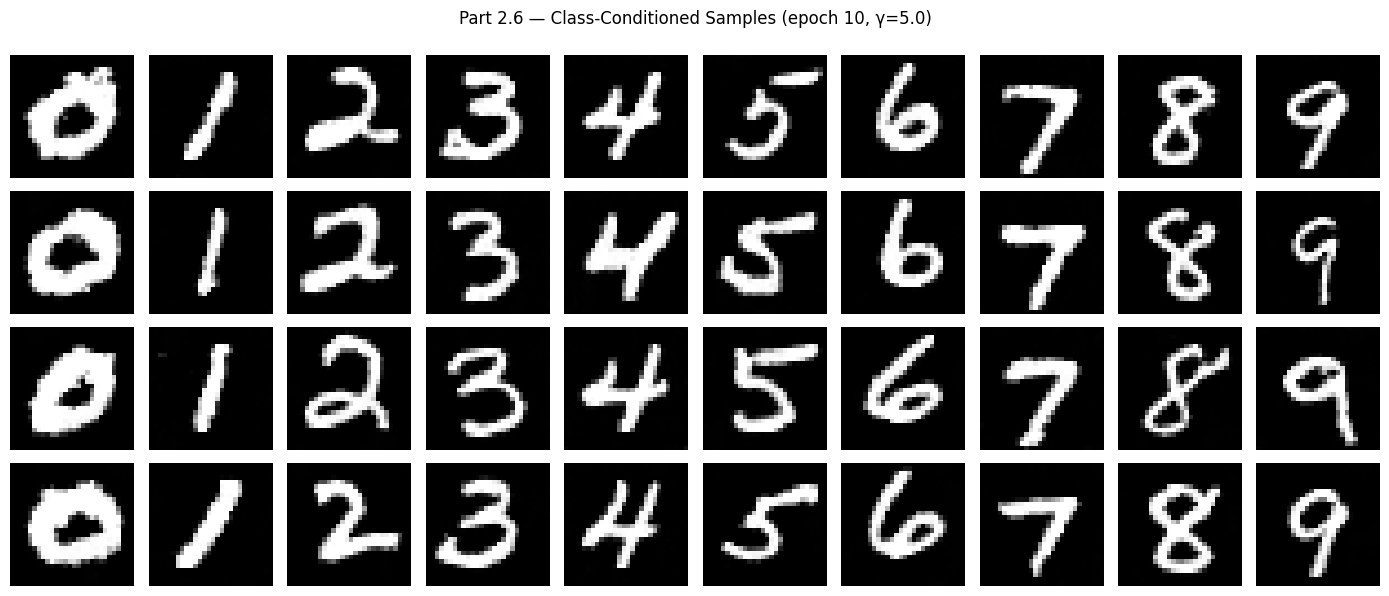

Saved: deliverables/part2_6_class_conditioned_epoch10.png


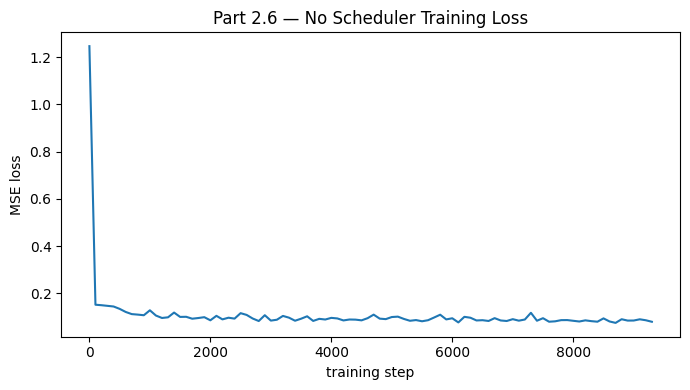

Saved: deliverables/part2_6_no_scheduler_loss_curve.png


In [ ]:
model_cc_nosched = ClassConditionedUNet(D=64, num_classes=10, p_uncond=0.1).to(device)
opt_nosched = torch.optim.Adam(model_cc_nosched.parameters(), lr=2e-3)
criterion = nn.MSELoss()

num_epochs = 10
log_every = 100
loss_hist_ns, step_hist_ns = [], []
step = 0

for epoch in range(1, num_epochs + 1):
    model_cc_nosched.train()
    for x0, y in train_loader:
        x0 = x0.to(device)
        y = y.to(device)

        eps = torch.randn_like(x0)
        t = torch.rand((x0.size(0),), device=device)
        xt = (1.0 - t).view(-1,1,1,1) * eps + t.view(-1,1,1,1) * x0
        v_star = x0 - eps

        opt_nosched.zero_grad()
        loss = criterion(model_cc_nosched(xt, t, y), v_star)
        loss.backward()
        opt_nosched.step()

        if step % log_every == 0:
            loss_hist_ns.append(loss.item())
            step_hist_ns.append(step)
            print(f"[no-sched] epoch {epoch} step {step} loss {loss.item():.6f}")
        step += 1

    if epoch in (10,):
        save_cc_grid(model_cc_nosched, epoch, n_per_digit=4, n_steps=300, gamma=5.0)

plt.figure(figsize=(7,4))
plt.plot(step_hist_ns, loss_hist_ns)
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Part 2.6 — No Scheduler Training Loss")
plt.tight_layout()
p = os.path.join(OUT_DIR, "part2_6_no_scheduler_loss_curve.png")
plt.savefig(p, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", p)